Pull camera-violation tickets (codes 6, 37) for each parking-violations fiscal year dataset, using `fetch_soda` from `data/download.py` so every pull is cached in the local DuckDB and logged in `_provenance`.

Each fiscal year is fetched in its own cell. Datasets are tens of millions of rows before filtering, so keeping the pulls separate means a failed or interrupted run only has to redo the year it stopped on — `fetch_soda` serves any year already in the cache straight from DuckDB instead of hitting the API again.

In [1]:
import sys
sys.path.append("..")

from data.download import fetch_soda

WHERE = "violation_code IN (7, 36)"

In [2]:
fetch_soda("2bnn-yakx", "tickets_fy2017", WHERE).shape

(1917003, 38)

In [3]:
fetch_soda("a5td-mswe", "tickets_fy2018", WHERE).shape

(1631425, 39)

In [4]:
fetch_soda("faiq-9dfq", "tickets_fy2019", WHERE).shape

(1570054, 39)

In [5]:
fetch_soda("p7t3-5i9s", "tickets_fy2020", WHERE).shape

(4173023, 38)

In [6]:
fetch_soda("kvfd-bves", "tickets_fy2021", WHERE).shape

tickets_fy2021 rows: 4643494 rows [12:51, 6018.43 rows/s] 


(4643494, 38)

In [7]:
fetch_soda("7mxj-7a6y", "tickets_fy2022", WHERE).shape

tickets_fy2022 rows: 5298606 rows [20:02, 4407.59 rows/s]


(5298606, 39)

In [8]:
fetch_soda("869v-vr48", "tickets_fy2023", WHERE).shape

tickets_fy2023 rows: 8931848 rows [35:14, 4223.56 rows/s] 


(8931848, 38)

In [9]:
fetch_soda("8zf9-spf8", "tickets_fy2024", WHERE).shape

tickets_fy2024 rows: 6285732 rows [22:28, 4661.88 rows/s]


(6285732, 39)

In [10]:
fetch_soda("m5vz-tzqv", "tickets_fy2025", WHERE).shape

tickets_fy2025 rows: 5590777 rows [26:32, 3511.08 rows/s]


(5590777, 38)

In [11]:
fetch_soda("9mwx-gamw", "tickets_fy2026", WHERE).shape

tickets_fy2026 rows: 4834120 rows [20:46, 3878.49 rows/s]


(4834120, 40)

In [12]:
fetch_soda("pvqr-7yc4", "tickets_fy2027", WHERE).shape

tickets_fy2027 rows: 1004802 rows [04:13, 3962.96 rows/s]


(1004802, 29)

In [13]:
# combine each fiscal year in DuckDB (UNION ALL BY NAME handles the extra
# column some years have) instead of pd.concat, so ~20M rows never have to
# sit in pandas all at once
from data.base import get_connection

FISCAL_YEAR_TABLES = [
    "tickets_fy2017",
    "tickets_fy2018",
    "tickets_fy2019",
    "tickets_fy2020",
    "tickets_fy2021",
    "tickets_fy2022",
    "tickets_fy2023",
    "tickets_fy2024",
    "tickets_fy2025",
    "tickets_fy2026",
    "tickets_fy2027",
]

con = get_connection()
try:
    union_sql = " UNION ALL BY NAME ".join(
        f"SELECT * FROM {table}" for table in FISCAL_YEAR_TABLES
    )
    con.execute(f"CREATE OR REPLACE TABLE tickets_all AS {union_sql}")
    row_count = con.execute("SELECT COUNT(*) FROM tickets_all").fetchone()[0]
finally:
    con.close()

row_count

45880884

Running these local pulls to DuckDB took a couple hours, despite efforts to optimize the indexing using a cursor, instead of page scanning. That being said, moving forward, DuckDB is able to execute SQL-like queries 

In [28]:
#do some basic eda of the combined tickets dataset
import pandas as pd

by_year = get_connection().sql("""
    SELECT COUNT(*) AS tickets,
           DATE_PART('year', CAST(issue_date AS TIMESTAMP)) AS year,
           violation_code
    FROM tickets_all
    GROUP BY DATE_PART('year', CAST(issue_date AS TIMESTAMP)), violation_code
    ORDER BY DATE_PART('year', CAST(issue_date AS TIMESTAMP)), violation_code
""").df()

by_year.head(20)


,tickets,year,violation_code
0,737846,2016,36
1,306217,2016,7
2,1259681,2017,36
3,515091,2017,7
4,1013212,2018,36
5,486522,2018,7
6,2350126,2019,36
7,429868,2019,7
8,4397339,2020,36
9,389422,2020,7


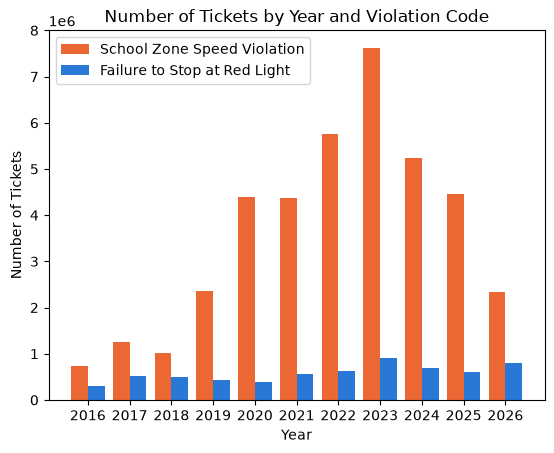

In [37]:
#for readability, note that violation_code 7 is "Failure to Stop at Red Light" and violation_code 36 is "School Zone Speed Violation"
violation_code_labels = {
    7: "Failure to Stop at Red Light",
    36: "School Zone Speed Violation"
}
violation_code_colors = {
    7: "#2a78d6",
    36: "#eb6834",
}

#make a grouped bar chart of the number of tickets by year and violation code
import matplotlib.pyplot as plt
import numpy as np

pivot = by_year.pivot(index="year", columns="violation_code", values="tickets")
pivot.columns = pivot.columns.astype(int)

x = np.arange(len(pivot.index))
width = 0.4
codes = list(pivot.columns)

fig, ax = plt.subplots()
for i, code in enumerate(codes):
    offset = (i - (len(codes) - 1) / 2) * width
    ax.bar(x + offset, pivot[code], width, label=violation_code_labels[code], color=violation_code_colors[code])

ax.set_xticks(x, pivot.index.astype(int))
ax.set_xlabel("Year")
ax.set_ylabel("Number of Tickets")
ax.set_title("Number of Tickets by Year and Violation Code")
ax.legend()
plt.show()

School zone speeding tickets VASTLY outnumber red light running tickets. This is an extremely valuable piece of context.

In [ ]:
#